In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("ML_input_VST.csv")
df = df.set_index(df.columns[0])
df.index.name = None

df_t = df.T
df_t.index.name = "gene"

df_t.to_csv("transposed_ml_vst.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'ML_input_VST.csv'

In [4]:

df = pd.read_csv("/content/transposed_ml_vst.csv")
df = df.set_index(df.columns[0])
df = df.T


In [5]:
y = np.array([0]*18 + [1]*18)
X = df.copy()
X = X.drop(columns=["Y"], errors="ignore")
assert X.shape[0] == len(y), "Mismatch between samples and labels"


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [7]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

In [9]:
svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

svm = SVC(probability=True)
svm_grid = GridSearchCV(
    svm, svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test_scaled)

In [10]:
svm_best = svm_grid.best_estimator_
print("Best Parameters:", svm_grid.best_params_)
print("Best CV F1 Score:", svm_grid.best_score_)


Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best CV F1 Score: 0.7647619047619048


In [14]:
svm_results_df = pd.DataFrame(svm_grid.cv_results_)
svm_results_df.to_csv("svm_all_grid_results.csv", index=False)

In [12]:
def evaluate(y_true, y_pred, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Sensitivity:", tp / (tp + fn))
    print("Specificity:", tn / (tn + fp))


evaluate(y_test, svm_pred, "SVM")



SVM
Accuracy: 0.75
F1 Score: 0.8
Sensitivity: 1.0
Specificity: 0.5


In [13]:
genes = X.columns

svm_genes = pd.Series(
    np.abs(svm_best.coef_[0]),
    index=genes
).sort_values(ascending=False).head(20)


/tmp/ipykernel_1478/3844798020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


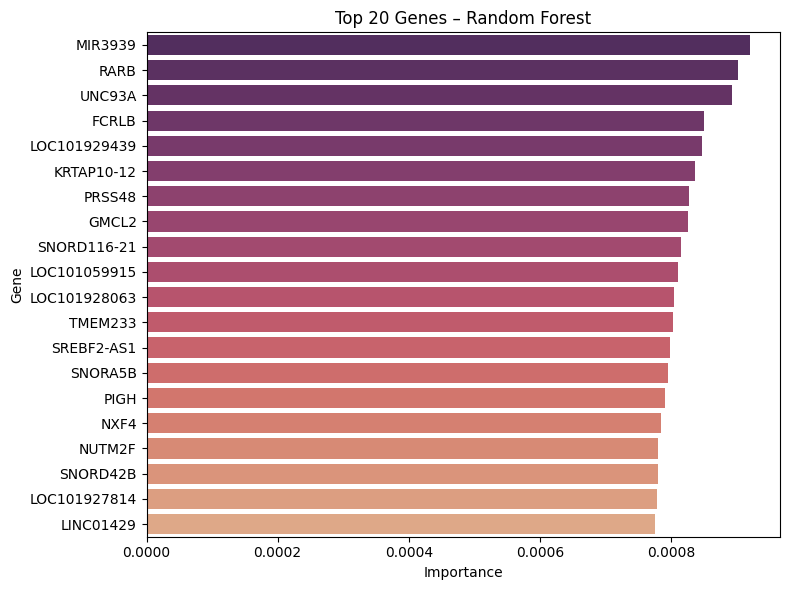

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=svm_genes.values,
    y=svm_genes.index,
    palette="flare_r"
)
plt.title("Top 20 Genes – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
svm_probs = svm_best.predict_proba(X_test_scaled)[:, 1]
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
svm_auc = auc(svm_fpr, svm_tpr)


In [ ]:
print("ROC-AUC Scores:")
print(f"SVM AUC: {svm_auc:.3f}")


In [ ]:
from sklearn.metrics import roc_curve, auc

In [ ]:
svm_probs = svm_best.predict_proba(X_test_scaled)[:, 1]
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
svm_auc = auc(svm_fpr, svm_tpr)

plt.figure(figsize=(6, 5))
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"SVM ROC-AUC: {svm_auc:.3f}")
